# Problem Statement:
Build a machine learning solution to predict the market value of a football player using the given features.
Additionally, you are required to evaluate the impact of dimensionality reduction (PCA) and hyperparameter tuning on model performance.


#1 Import Required Libraries

In [1]:
#Import Required Libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')


In [2]:
#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Preprocessing
from sklearn.preprocessing import  StandardScaler,LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.ensemble import RandomForestRegressor


In [4]:
#Evaluation Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score


#2. Load the Dataset

In [5]:
# from google.colab import files
# uploaded = files.upload()


In [6]:
df=pd.read_csv("/content/player_stats.csv", encoding='latin-1')

In [7]:
df.head()

,player,country,height,weight,age,club,ball_control,dribbling,marking,slide_tackle,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,Cristian Castro Devenish,Colombia,192,84,22,Atl. Nacional,55,43,NaN,68,...,32,34,41,33,10,11,6,7,9,$1.400.000
1,Silaldo Taffarel,Brazil,181,80,31,Corinthians,69,70,NaN,56,...,65,62,48,46,12,15,14,8,14,$975.00
2,Thomas DÃ¤hne,Germany,193,84,29,Holstein Kiel,25,12,NaN,13,...,20,15,26,16,64,74,65,68,74,$1.100.000
3,Michael Sollbauer,Austria,187,86,33,SK Rapid Wien,46,48,NaN,66,...,25,13,22,19,10,10,8,14,9,$650.00
4,Diego Segovia,Uruguay,191,80,23,Independiente,14,8,NaN,14,...,9,10,16,5,61,59,62,64,64,$300.00


#Basic Datacheck

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5682 entries, 0 to 5681
Data columns (total 41 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   player          5682 non-null   object 
 1   country         5682 non-null   object 
 2   height          5682 non-null   int64  
 3   weight          5682 non-null   int64  
 4   age             5682 non-null   int64  
 5   club            5682 non-null   object 
 6   ball_control    5682 non-null   int64  
 7   dribbling       5682 non-null   int64  
 8   marking         0 non-null      float64
 9   slide_tackle    5682 non-null   int64  
 10  stand_tackle    5682 non-null   int64  
 11  aggression      5682 non-null   int64  
 12  reactions       5682 non-null   int64  
 13  att_position    5682 non-null   int64  
 14  interceptions   5682 non-null   int64  
 15  vision          5682 non-null   int64  
 16  composure       5682 non-null   int64  
 17  crossing        5682 non-null   i

In [9]:
df.shape

(5682, 41)

Comment:There are 5682 rows and 41 columns in the dataset.

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
height,5682.0,181.670539,6.829238,156.0,177.0,182.0,186.0,204.0
weight,5682.0,75.282295,6.998971,54.0,70.0,75.0,80.0,102.0
age,5682.0,26.316262,4.729967,17.0,23.0,26.0,30.0,41.0
ball_control,5682.0,58.912179,16.567068,8.0,55.0,63.0,69.0,94.0
dribbling,5682.0,56.128476,18.772075,5.0,51.0,62.0,68.0,95.0
marking,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
slide_tackle,5682.0,46.728441,20.519430,7.0,27.0,54.0,64.0,87.0
stand_tackle,5682.0,48.820838,20.975966,7.0,30.0,57.0,66.0,91.0
aggression,5682.0,56.324006,16.846410,11.0,45.0,60.0,69.0,96.0
reactions,5682.0,61.959345,8.893309,32.0,56.0,62.0,68.0,93.0


#3. Data Cleaning

Drop non-informative/constant columns.

In [11]:
df=df.drop(['player','marking'],axis=1)

Comment: Deleted non informative column 'player','marking'.

In [12]:
#Check for null values
# 1. Standard missing values (NaN)
missing_counts = df.isnull().sum()
print("Missing values per column:\n", missing_counts[missing_counts > 0])

# 2. Blank strings ("")
blank_counts = (df.applymap(lambda x: str(x).strip() == '')).sum()
print("\nBlank string counts per column:\n", blank_counts[blank_counts > 0])

# 3. "Unknown" or placeholder values
unknown_counts = (df.applymap(lambda x: str(x).lower() in ['unknown','na','n/a','none'])).sum()
print("\n'Unknown' placeholder counts per column:\n", unknown_counts[unknown_counts > 0])

# 4. Combined summary
summary = pd.DataFrame({
    "NaN": missing_counts,
    "Blank": blank_counts,
    "Unknown": unknown_counts
})
print("\nSummary of missing/blank/unknown values:\n", summary)


Missing values per column:
 Series([], dtype: int64)

Blank string counts per column:
 Series([], dtype: int64)

'Unknown' placeholder counts per column:
 Series([], dtype: int64)

Summary of missing/blank/unknown values:
                 NaN  Blank  Unknown
country           0      0        0
height            0      0        0
weight            0      0        0
age               0      0        0
club              0      0        0
ball_control      0      0        0
dribbling         0      0        0
slide_tackle      0      0        0
stand_tackle      0      0        0
aggression        0      0        0
reactions         0      0        0
att_position      0      0        0
interceptions     0      0        0
vision            0      0        0
composure         0      0        0
crossing          0      0        0
short_pass        0      0        0
long_pass         0      0        0
acceleration      0      0        0
stamina           0      0        0
strength          0  

Comment:There are no null  or error values values in a dataset.

In [13]:
#Check for duplicate records
df.duplicated().sum()

np.int64(3)

Comment: There are 3 duplicate records in a dataset.

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.shape

(5679, 39)

Comment:After deleting duplicate records there are 5679 rows are left in a dataset.

In [16]:
#Split data into categorical and numerical columns
categorical_columns=df.select_dtypes(include='object').columns
numerical_columns=df.select_dtypes(exclude='object').columns

Comment: Splited  data into categorical and numerical columns for further processing.


In [17]:
categorical_columns

Index(['country', 'club', 'value'], dtype='object')

In [18]:
numerical_columns

Index(['height', 'weight', 'age', 'ball_control', 'dribbling', 'slide_tackle',
       'stand_tackle', 'aggression', 'reactions', 'att_position',
       'interceptions', 'vision', 'composure', 'crossing', 'short_pass',
       'long_pass', 'acceleration', 'stamina', 'strength', 'balance',
       'sprint_speed', 'agility', 'jumping', 'heading', 'shot_power',
       'finishing', 'long_shots', 'curve', 'fk_acc', 'penalties', 'volleys',
       'gk_positioning', 'gk_diving', 'gk_handling', 'gk_kicking',
       'gk_reflexes'],
      dtype='object')

# Clean target variable

In [19]:
# import re

# def clean_value(val):
#     if pd.isna(val):
#         return None
#     val = str(val).replace('$','').strip()
#     val = re.sub(r'(?<=\d)[.,](?=\d{3})','', val)  # remove thousand separators
#     return float(val)

# df['value_new'] = df['value'].apply(clean_value)

In [20]:
import re


def clean_value(val):
    if pd.isna(val):
        return None

    # Remove $ and spaces
    val = str(val).replace('$','').strip()

    # Case 1: Only one dot → decimal
    if val.count('.') == 1:
        return float(val)

    # Case 2: Two dots → first is thousand separator, second is decimal
    elif val.count('.') == 2:
        # Replace the first dot (thousand separator) with nothing
        parts = val.split('.')
        # Example: "1.200.00" → ['1','200','00']
        new_val = parts[0] + parts[1] + '.' + parts[2]
        return float(new_val)

    # Case 3: More than 2 dots (rare) → remove all thousand separators except last
    elif val.count('.') > 2:
        # Keep last dot as decimal, remove others
        last_dot = val.rfind('.')
        new_val = val[:last_dot].replace('.','') + val[last_dot:]
        return float(new_val)

    # Case 4: No dot → just convert
    else:
        return float(val)

# Apply to your dataframe
df['value'] = df['value'].apply(clean_value)

In [21]:
df

,country,height,weight,age,club,ball_control,dribbling,slide_tackle,stand_tackle,aggression,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,Colombia,192,84,22,Atl. Nacional,55,43,68,73,72,...,32,34,41,33,10,11,6,7,9,1400.0
1,Brazil,181,80,31,Corinthians,69,70,56,58,62,...,65,62,48,46,12,15,14,8,14,975.0
2,Germany,193,84,29,Holstein Kiel,25,12,13,16,27,...,20,15,26,16,64,74,65,68,74,1100.0
3,Austria,187,86,33,SK Rapid Wien,46,48,66,69,71,...,25,13,22,19,10,10,8,14,9,650.0
4,Uruguay,191,80,23,Independiente,14,8,14,16,28,...,9,10,16,5,61,59,62,64,64,300.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5677,Egypt,175,71,31,Liverpool,86,88,41,43,63,...,84,69,86,83,11,14,14,9,14,99500.0
5678,Senegal,174,69,31,FC Bayern München,86,88,38,42,75,...,77,64,75,75,7,10,10,15,14,101000.0
5679,Brazil,175,68,31,Paris SG,94,95,29,32,63,...,88,87,91,86,15,9,9,15,11,99500.0
5680,Portugal,187,83,38,Al Nassr,87,81,24,32,62,...,79,75,90,85,14,7,11,15,11,31000.0


#Outlier Detection

In [22]:
#Outlier detection
for col in numerical_columns:
  q1=df[col].quantile(0.25)
  q3=df[col].quantile(0.75)
  iqr=q3-q1
  lower_bound=q1-1.5*iqr
  upper_bound=q3+1.5*iqr
  outliers=df[(df[col]<lower_bound) | (df[col]>upper_bound)]
  df_clean=df[(df[col]>=lower_bound)&(df[col]<=upper_bound)]
print("Outliers:",len(outliers))
print("------"*50)

Outliers: 632
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


In [23]:
df_clean.shape

(5047, 39)

Comment:There are 632 outliers in the dataset.

#4 Univariate Analysis and Bivariate Analysis

# Univariate Analysis of 'country' variable.

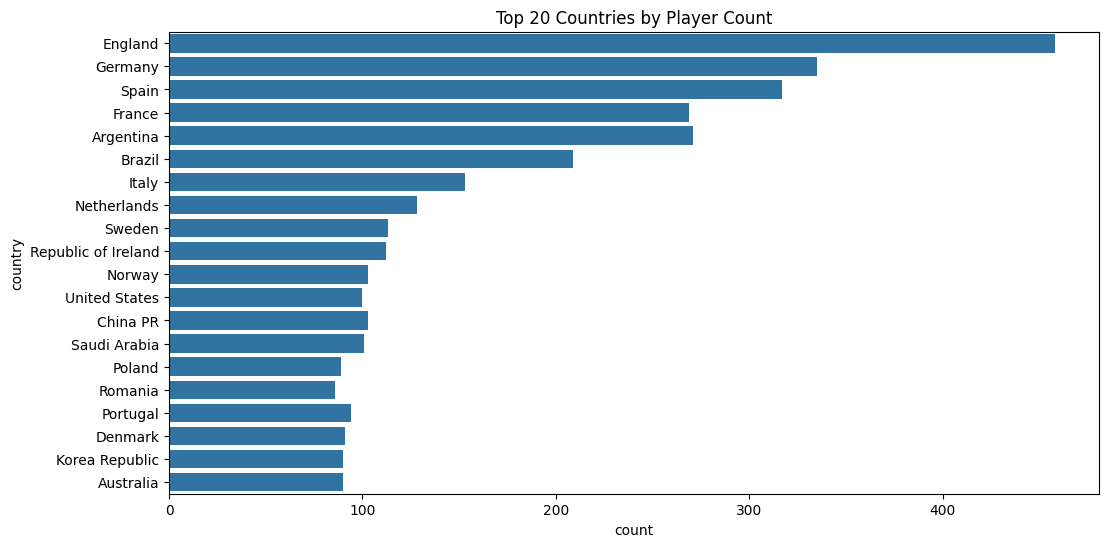

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.countplot(y='country', data=df_clean, order=df['country'].value_counts().index[:20])
plt.title("Top 20 Countries by Player Count")
plt.show()


Comment:

*   England has the highest no of players ,standing out as the largest contributor.

*   Germany and Spain follow closely,showing strong representation in the dataset.

*   England ,Germany,Spain,France and Argentina are the TOP 5 countries which are countributing  towards the player.
*   While the top 5–6 countries dominate, the presence of smaller contributors (e.g., Romania, Saudi Arabia, Australia) suggests a long tail distribution — many countries contribute fewer players but still add diversity.







In [25]:
# Frequency counts
country_counts = df_clean['country'].value_counts()

# Total players
total_players = len(df)

# Top 5 contribution
top5_share = (country_counts.head(5).sum() / total_players) * 100

# Top 10 contribution
top10_share = (country_counts.head(10).sum() / total_players) * 100

print(f"Total players: {total_players}")
print(f"Top 5 countries contribute: {top5_share:.2f}% of all players")
print(f"Top 10 countries contribute: {top10_share:.2f}% of all players")


Total players: 5679
Top 5 countries contribute: 29.05% of all players
Top 10 countries contribute: 41.64% of all players


Comment:
*   Total players: 5679
*   Top 5 countries contribute: 29.05% of all players
*   Top 10 countries contribute: 41.64% of all players
*   This gives us a numerical confirmation of what the bar chart already shows visually — that a handful of countries dominate the dataset.




# Univariate analysis for  'club' variable.

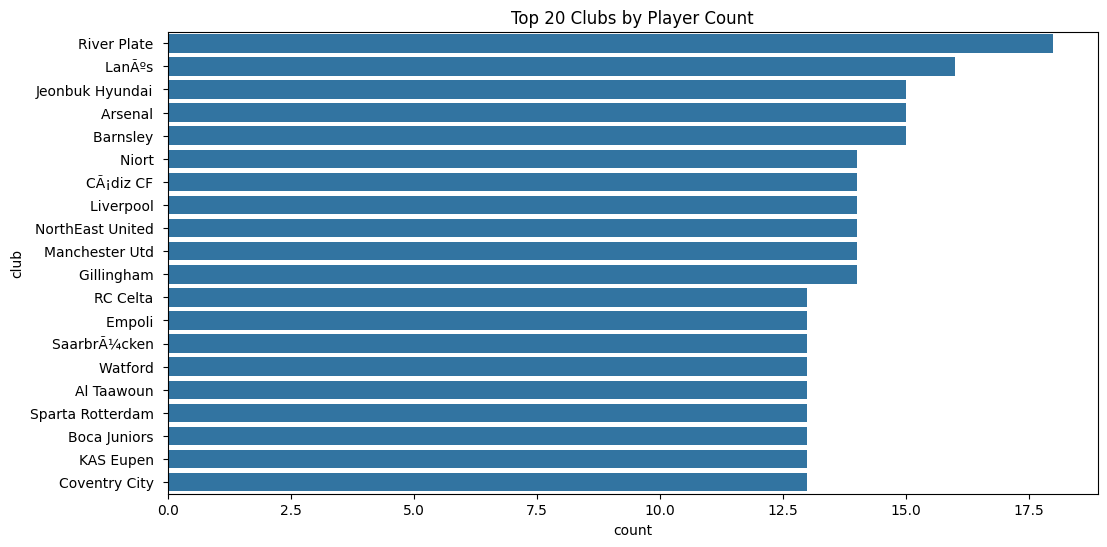

In [26]:

plt.figure(figsize=(12,6))
sns.countplot(y='club', data=df_clean, order=df_clean['club'].value_counts().index[:20])
plt.title("Top 20 Clubs by Player Count")
plt.show()


Comment:


*   River plate has the highest player count,showing its strong represenation in the dataset.

*   Liverpool and Lanús follow as second highest contributor.

*   While River Plate and Liverpool dominate, many clubs have moderate player counts.
*  The spread suggests that no single club dominates the dataset, representation is distributed across multiple leagues and countries.

*  The dataset is not biased only toward top-tier clubs, but covers a broader football ecosystem.







# Univariate analysis of 'Age' variable

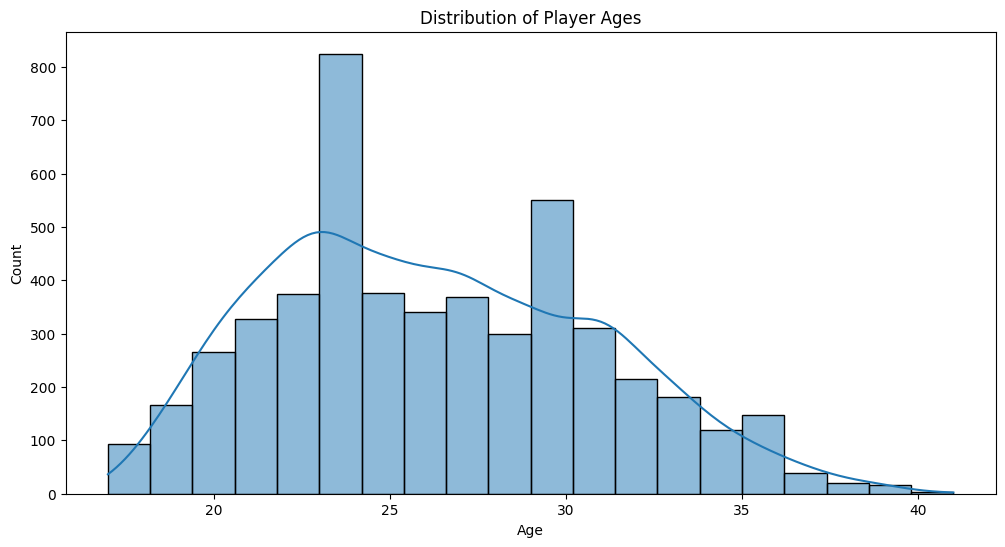

In [27]:
plt.figure(figsize=(12,6))
sns.histplot(df_clean['age'],bins=20,kde=True)
plt.title("Distribution of Player Ages")
plt.xlabel("Age")
plt.show()

Comment:


*   The highest concentration of player is around age 24,with more than 800 players

*   This sugegsts that most professionals are in their early to mid-20s.
*   There is small peak around 30,cluster of experienced players who are active but are lesser in no.


*   This reflects the balance between prime-age athelets andseasoned veterans.
*   After 30,the distribution slowly declines with very few players above 35.

*   This highlights the short career span in football.



# Univariate analysis of 'Value' variable.

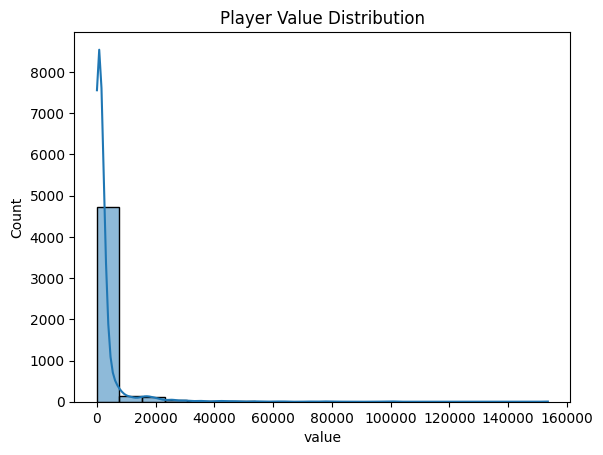

In [28]:
sns.histplot(df_clean['value'],bins=20,kde=True)
plt.title('Player Value Distribution')
plt.show()



Comment:This graph shows the distribution of football player market values.


*   The histogram is heavily right-skewed. Most players have relatively low market values clustered near the left side of the x-axis.

*    A long tail stretches toward the higher end, meaning a small number of players have extremely high values compared to the majority.




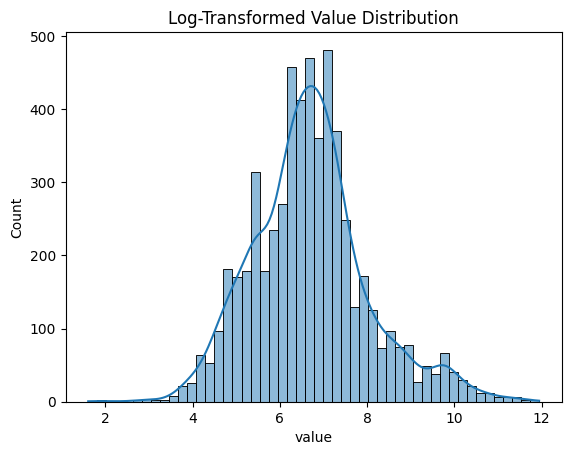

In [29]:
# Log-transformed distribution
sns.histplot(np.log1p(df["value"]), bins=50, kde=True)  # log1p handles zeros safely
plt.title("Log-Transformed Value Distribution")
plt.show()


Comment:This graph shows the log-transformed distribution of player market values.


*   Shape: Unlike the raw distribution (which was heavily right-skewed), this one is much closer to a bell curve. The histogram bars and smooth density curve suggest an approximately normal distribution.


*   Center: Most values cluster around the middle range. That means the majority of players having moderate values once the skew is corrected.

*   Spread: The distribution is more balanced, with fewer extreme outliers dominating the scale.



The log transformation compresses very high player values and expands the lower ones, making the data more symmetric. This is ideal for regression modeling because many algorithms assume normally distributed targets or benefit from reduced skewness.



# 5.Encoding Categorical Variables

In [30]:
categorical_columns

Index(['country', 'club', 'value'], dtype='object')

In [31]:
#Label encoding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in categorical_columns:
  df_clean[i]=le.fit_transform(df_clean[i])

In [32]:
df_clean.head()

,country,height,weight,age,club,ball_control,dribbling,slide_tackle,stand_tackle,aggression,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,24,192,84,22,62,55,43,68,73,72,...,32,34,41,33,10,11,6,7,9,57
1,14,181,80,31,153,69,70,56,58,62,...,65,62,48,46,12,15,14,8,14,52
3,8,187,86,33,534,46,48,66,69,71,...,25,13,22,19,10,10,8,14,9,39
6,120,194,88,25,74,52,43,71,72,63,...,29,22,34,34,10,5,14,12,5,59
7,100,185,75,20,90,41,33,65,70,46,...,26,26,39,25,7,6,12,13,11,21


Comment: Converted categorical columns to numerical columns.

#Bivariate analysis

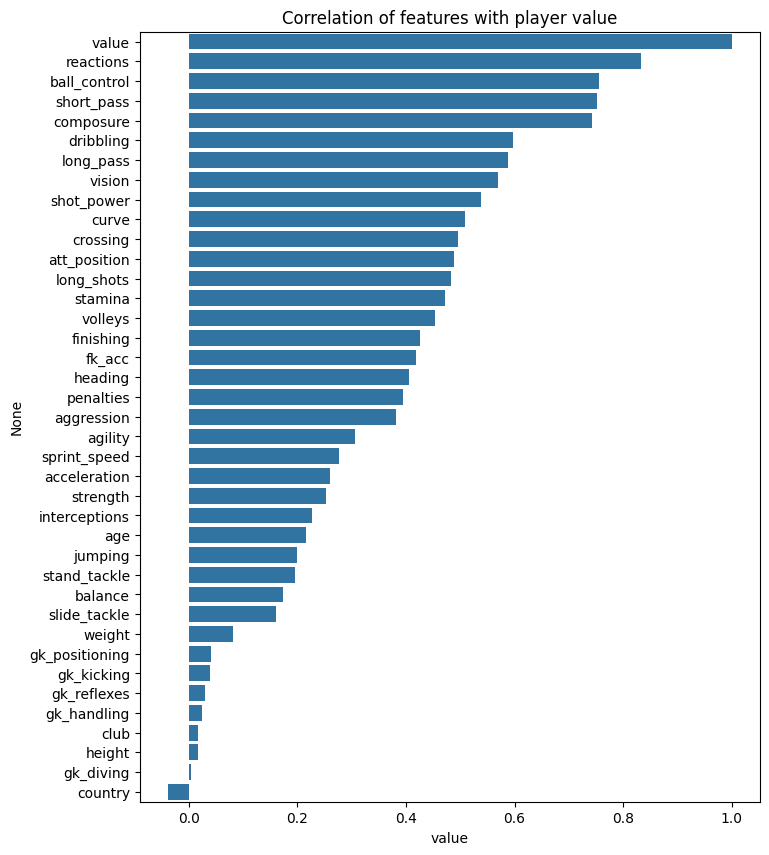

In [33]:
#Correlation of features with Player value
plt.figure(figsize=(8,10))
corr_target=df_clean.corr()['value'].sort_values(ascending=False)
sns.barplot(x=corr_target,y=corr_target.index)
plt.title("Correlation of features with player value")
plt.show()


Comment:

- Strongest correlations with player value:
    - Attributes such as reactions, ball control, short pass, composure, dribbling, and vision show the highest positive correlation. These skills reflect technical ability and mental sharpness, confirming their importance in determining player valuation.
- Moderately correlated attributes:
    - Features like shot power, curve, crossing, attacking position, long shots, and stamina also contribute meaningfully, highlighting the role of offensive creativity and physical endurance.
- Weak or negligible correlations:
    - Goalkeeping attributes (gk_diving, gk_handling, gk_reflexes, gk_positioning, gk_kicking), as well as physical traits like height, weight, and categorical features (club, country), show little to no correlation with player value. This suggests that market valuation is driven more by outfield performance than by goalkeeping or static physical measures.
* Club & Country correlations are weak individually, but they matter indirectly (elite clubs/nations tend to have higher-value players).




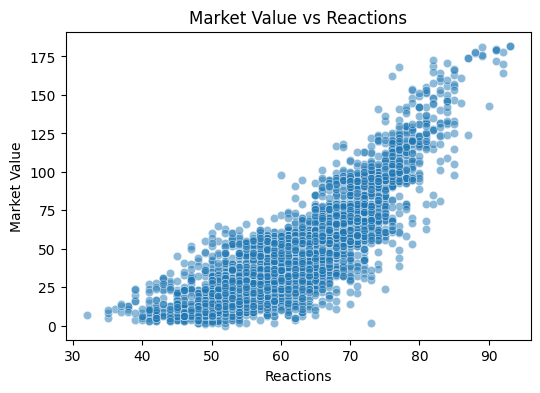

In [34]:
# 1. Scatterplot: Market Value vs Reactions
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_clean, x='reactions', y='value', alpha=0.5)
plt.title('Market Value vs Reactions')
plt.xlabel('Reactions')
plt.ylabel('Market Value')
plt.show()




Comment:


* As reaction scores increase, player market value generally rises. Players with quicker reactions are valued more highly.
* Most low‑reaction players cluster at the lower end of market value, while high‑reaction players spread upward, showing greater valuation potential.
* A few players with exceptionally high values stand out even among strong reaction scores, suggesting elite talent or reputation factors.
* Reactions are a critical technical attribute influencing valuation — clubs should prioritize scouting players with strong reaction skills, as this trait directly boosts market worth.



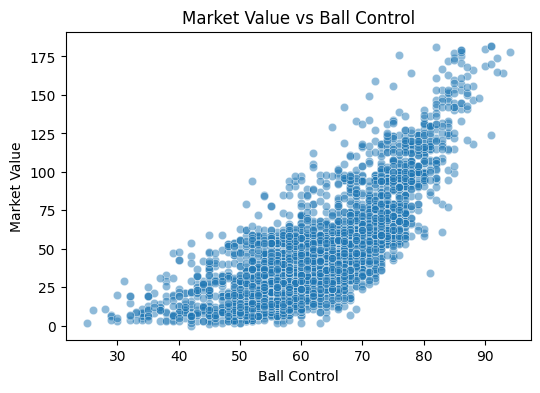

In [35]:

# 2. Scatterplot: Market Value vs Ball Control
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_clean, x='ball_control', y='value', alpha=0.5)
plt.title('Market Value vs Ball Control')
plt.xlabel('Ball Control')
plt.ylabel('Market Value')
plt.show()


Comment:

*   Player with higher ball control have higher market values.
*   Most players fall in the 50-90 ball control range, where market values vary widely but goes upward.
*   At lower ball control levels, market values remain modest, but once ball control exceeds ~70, values rise sharply
*   Ball control is a critical skill for clubs to prioritize in scouting and recruitment, as it strongly influences player worth and transfer potential.









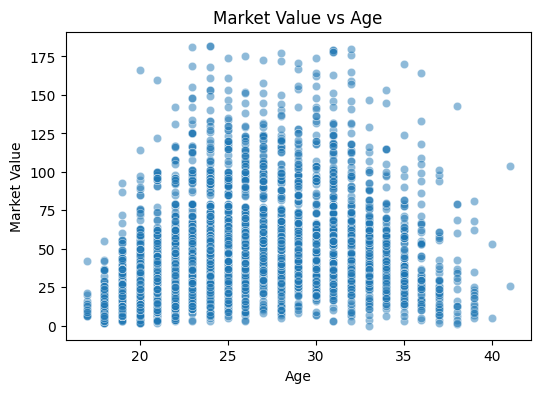

In [36]:
# 3. Scatterplot: Market Value vs Age
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_clean, x='age', y='value', alpha=0.5)
plt.title('Market Value vs Age')
plt.xlabel('Age')
plt.ylabel('Market Value')
plt.show()

Comment:


* Player values are highest in the mid‑20s.
* Market values drop noticeably beyond age 35, shows shorter career span.
* Most players fall between ages 20–35 with values below 100,000, showing where the bulk of the market lies.
* Age is a critical valuation driver — clubs should focus on acquiring players in their prime years (20–27)



#6. Feature and Target split

Define features (X) and (y)

In [ ]:
X=df_clean.drop('value',axis=1)
y=df_clean['value']

Comment: define features except value are input variables and value is target variable.

# 7. Standardization

In [ ]:
ss=StandardScaler()
X_scaled=ss.fit_transform(X)

Comment: Scaled down all the input variables to same scale of mean=0 and standard deviation of 1.

#8 PCA: Principal Component analysis

In [ ]:
pca=PCA()
X_pca=pca.fit_transform(X_scaled)

Comment: Applied PCA to input features to reduce dimensionality.

In [ ]:
explained_variance=pca.explained_variance_ratio_

Comment: How much variance each component explains is calculated.

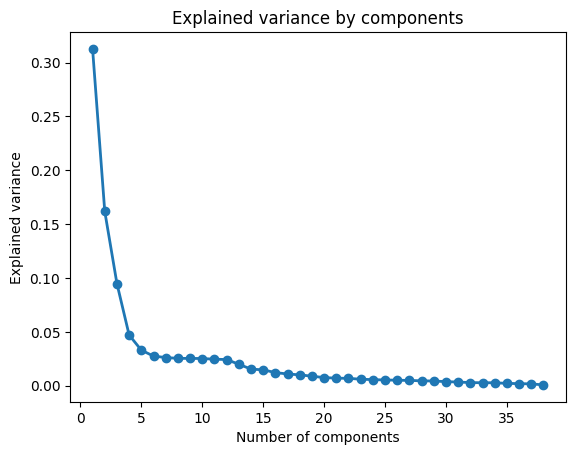

In [ ]:
#Plot

plt.figure()
plt.plot(range(1,len(explained_variance)+1),explained_variance,'o-',linewidth=2)
plt.title("Explained variance by components")
plt.xlabel("Number of components")
plt.ylabel("Explained variance")
plt.show()



*  The first component explains the largest share of variance


* The curve drops sharply after the first few components,meaning most of the useful information is concentrated in the first few PCs.


*   Beyond ~5 components, the explained variance per component is very small (close to zero), so adding more components doesn’t add much new information.






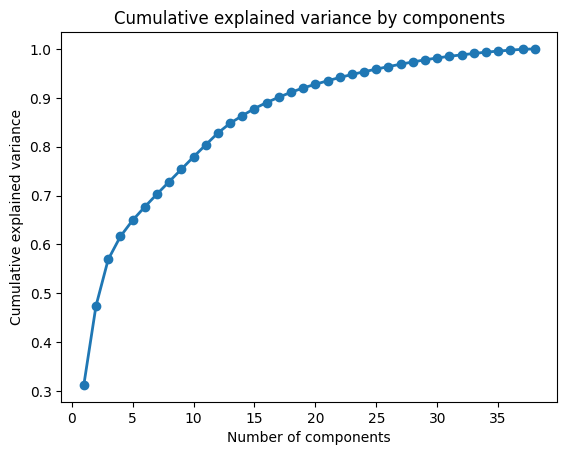

In [ ]:
#Cumulative variance plot

cumulative_variance=np.cumsum(explained_variance)

plt.figure()
plt.plot(range(1,len(cumulative_variance)+1),cumulative_variance ,'o-',linewidth=2)
plt.title("Cumulative explained variance by components")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.show()




*   The curve rises at first ,the first few components capture most of the variance in a dataset

* It then gradually flattens means additional components add only small amounts of new information.  
*   In this plot, the curve approaches 1.0 (100%) as you include more components.
*   We will choose num of components where curve crosses 95%



# Select optimal components

In [ ]:
n_components=np.argmax(cumulative_variance>=0.95)+1
print(f"Optimal no of components: {n_components}")

Optimal no of components: 24


Comment:Optimal No of components are: 24

1.   24 principal components are required to retain at least 95% of the variance in your dataset.
2.   This means we can safely reduce dataset to 24 dimensions while still preserving nearly all the information.



In [ ]:
#Apply PCA with 24 components

pca=PCA(n_components=24)
X_pca=pca.fit_transform(X_scaled)



In [ ]:
X_pca.shape

(5047, 24)

Train Test Split

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X_pca,y,test_size=0.2,random_state=42)

Comment: Data with reduced dimensions is splited into train and test data to train the models with test size-20%.

#9 Baseline Model Building

#1. Linear Regression baseline model

In [ ]:
from sklearn.metrics import mean_absolute_error

#Linear Regression baseline model

lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)

#Evaluation

print("R2 Score:",r2_score(y_test,y_pred))
print("MSE : ",mean_squared_error(y_test,y_pred))
print("MAE : ",mean_absolute_error(y_pred,y_test))


R2 Score: 0.828667594650928
MSE :  165.500386147782
MAE :  9.758961110970189


Comment:


*   R² Score (0.828) → Model explains about 83% of the variance in the target variable. That’s strong, especially for real-world data where perfect fits are rare.


*   MSE (165.5) → On average, the squared error is around 165. This penalizes larger errors more heavily, so it’s useful for spotting whether model occasionally makes big mistakes.
*   MAE (9.76) → The average absolute error is under 10 units, which is quite interpretable — it means your predictions are typically off by about 10 units in the target’s scale.








Comment:Plain Linear Regression has almost no tunable hyperparameters.

#2.Random Forest Baseline Model

In [ ]:
# Random Forest Baseline model
from sklearn.ensemble import RandomForestRegressor


rf=RandomForestRegressor()
rf.fit(X_train,y_train)
rf_y_pred=rf.predict(X_test)

#Evaluation
print("R2 : ",r2_score(y_test,rf_y_pred))
print("MSE : ",mean_squared_error(y_test,rf_y_pred))
print("MAE : ",mean_absolute_error(rf_y_pred,y_test))


R2 :  0.9026052383656906
MSE :  94.07952118811882
MAE :  6.898554455445544


Comment:


1.   R² = 0.90 → explains  90% of the variance, a clear improvement over the linear regression’s ~0.83.

2.   MSE = 94.07 → much lower than the linear regression’s ~165.5, meaning squared errors are significantly reduced
3.   MAE = 6.89 → average prediction error dropped from ~9.76 to ~7, so predictions are closer to actual values.






# Key Points:

*   Random Forest is capturing non-linear relationships in the data that linear regression cannot.


*  The reduction in both MSE and MAE shows that errors are not only smaller on average but also less extreme.


*   The higher R² confirms that Random Forest explains more of the variability in player values.




#3. Decision Tree Baseline model


In [ ]:

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

dt_reg = DecisionTreeRegressor()
dt_reg.fit(X_train, y_train)
dt_y_pred = dt_reg.predict(X_test)

# Evaluation metrics
print("R2 : ",r2_score(y_test,rf_y_pred))
print("MSE : ",mean_squared_error(y_test,rf_y_pred))
print("MAE : ",mean_absolute_error(rf_y_pred,y_test))



R2 :  0.9026052383656906
MSE :  94.07952118811882
MAE :  6.898554455445544


Comment:


1.   R² = 0.90 → explains  90% of the variance, a clear improvement over the linear regression’s ~0.83.

2.   MSE = 94.07 → much lower than the linear regression’s ~165.5, meaning squared errors are significantly reduced
3.   MAE = 6.89 → average prediction error dropped from ~9.76 to ~7, so predictions are closer to actual values.






# Comment:The Random Forest and Decision Tree baseline models show almost identical evaluation metric values.


#10. Model Improvement using Grid SearchCV(Random Forest)

Hyperparameter Tuning(Random Forest)

In [ ]:
param_grid={
  "n_estimators": [100, 150, 50],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

# Initialize model
rf = RandomForestRegressor(random_state=42)

# GridSearchCV setup
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                # 5-fold cross-validation
    scoring='r2',        # optimize for R²
    n_jobs=-1            # use all cores
)

#fit on training data
grid.fit(X_train,y_train)


#Best parameters and CV score

print("Best Parameters : ",grid.best_params_)
print("Best CV : ", grid.best_score_)

#Evaluate on test set
best_model=grid.best_estimator_
y_pred_best=best_model.predict(X_test)

print("Test R2 : ",r2_score(y_test,y_pred_best))
print("Test MSE : ",mean_squared_error(y_test,y_pred_best))
print("Test MAE : ",mean_absolute_error(y_pred_best,y_test))





Best Parameters :  {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 150}
Best CV :  0.8777530697923777
Test R2 :  0.902709078251581
Test MSE :  93.97921592959297
Test MAE :  6.849993399339934


Comment:


1.   Best CV Score = 0.878 → Strong cross-validation performance, showing consistency across folds

2.   Test R² = 0.903 → The model explains 90% of the variance in unseen data — a big jump from your linear regression (~0.83).
3.   Test MSE ≈ 94 → Errors are much smaller compared to linear regression (~165).


4.   Test MAE ≈ 6.85 → On average, predictions are off by less than 7 units — a meaningful improvement from ~10 units.



#Key Insights

- Without GridSearchCV: Already strong baseline (R² ≈ 0.90).
- With GridSearchCV: Slight improvements across all metrics, confirming that hyperparameter tuning helps squeeze out extra performance and stability.
- The tuned Random Forest is a better choice , but the gains are incremental ,the big jump was already achieved moving from Linear Regression.


#11.Feature Importance(Key for Business Insights)


In [ ]:
#feature Importance Analysis

importances=best_model.feature_importances_

# Create feature names for the PCA components
pca_feature_names = [f'PC_{i+1}' for i in range(len(importances))]

feature_importance_df=pd.DataFrame(
    {
        'Feature': pca_feature_names, # Use names for PCA components
        'Importance':importances
        }
).sort_values(by='Importance',ascending=False)
print(feature_importance_df.head(10))

   Feature  Importance
0     PC_1    0.573467
1     PC_2    0.189122
2     PC_3    0.068465
3     PC_4    0.030228
4     PC_5    0.022348
12   PC_13    0.014538
17   PC_18    0.012349
6     PC_7    0.008086
13   PC_14    0.007924
11   PC_12    0.007246


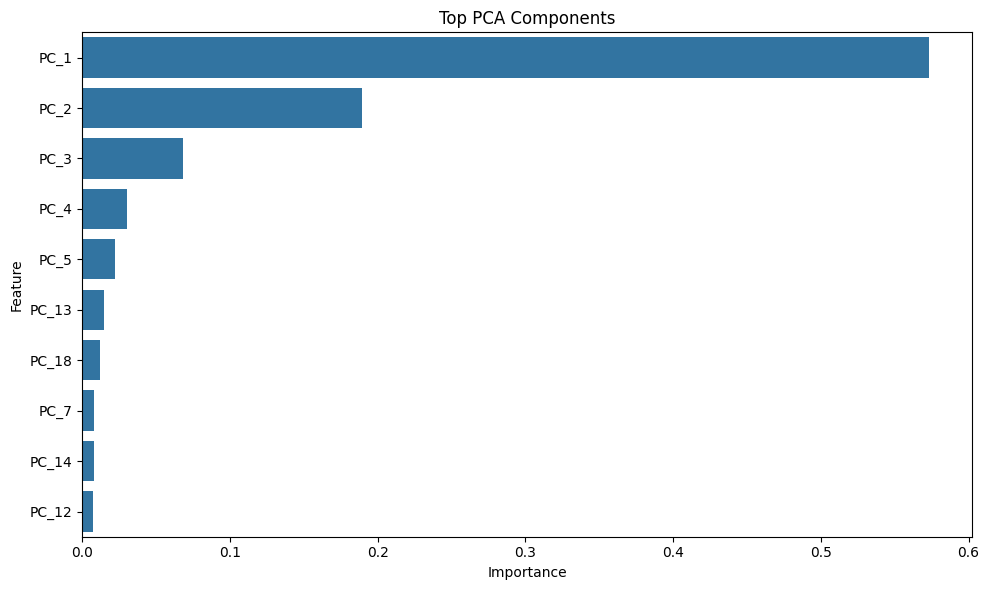

In [ ]:
# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title("Top PCA Components")
plt.tight_layout()
plt.show()



Comment:
- Dominant Components
  - PC1 explains the largest share of variance (close to 60%).
  - PC2 contributes around 20%.
  - Together, the first two components capture ~80% of the dataset’s        variability.
- Moderate Contribution
  - PC3 adds ~10%, bringing the cumulative explained variance to ~90%.
  - Beyond PC3, the contribution of each component drops sharply.
- Long Tail of Components
  - Components like PC4, PC5, PC7, PC12, PC13, PC14, PC18 contribute very little individually (<5%).


#12. Features contributing to Highest importance component PC1

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=X.columns
)

# Sort features by their contribution to PC1
pc1_loadings = loadings['PC1'].sort_values(ascending=False)

print("Top features contributing to PC1:")
print(pc1_loadings.head(10))



Top features contributing to PC1:
dribbling       0.261507
long_shots      0.254531
vision          0.254513
ball_control    0.254090
att_position    0.253016
curve           0.250961
finishing       0.241986
volleys         0.238746
shot_power      0.233177
fk_acc          0.231007
Name: PC1, dtype: float64


Comment:
*   PC1 captures the strongest variance in the dataset (~60%), meaning it represents the most influential combination of attributes.
*   The features with the highest loadings on PC1 are primarily attacking and
technical skills, which strongly differentiate players.

*   Top Features Driving PC1:
    *   Dribbling
    *   Long shots
    *   Vision
    *   Ball control
    *   Attacking positioning
    *   Curve
    *   Finishing
    *   Volleys
    *   Shot power
    *   Free kick accuracy


#Key Insights

*   PC1 is essentially an “Attacking Skill Component”.
*   Players with high PC1 scores are likely strong attackers with technical proficiency.
*   This makes PC1 a critical axis for evaluating market value and performance potential, as attacking skills often drive player demand and pricing.
